The primary objective of this analysis is to build and evaluate a time series forecasting model using a Long Short-Term Memory (LSTM) neural network to predict retail demand (units_sold). The model considers various features such as day of the week, weekend status, specific seasonal spikes (like 'third Thursday'), promotional activities, and holidays.

In [25]:
import numpy as np
import pandas as pd

In [26]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Set seed for reproducibility
np.random.seed(42)


In [27]:

# 1. Setup Timeframe (1000 days)
start_date = datetime(2023, 1, 1)
dates = [start_date + timedelta(days=i) for i in range(1000)]


In [28]:

# 2. Initialize Features
df = pd.DataFrame({'date': dates})
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)


In [29]:

# 3. Create "Complex Seasonality" (The Third Thursday Spike)
# Check if it's Thursday (3) and if the day of month is between 15-21
df['is_third_thursday'] = df['date'].apply(
    lambda x: 1 if (x.weekday() == 3 and 15 <= x.day <= 21) else 0
)


In [30]:

# 4. Add Promotions (Randomly assigned to 15% of days)
df['on_promotion'] = np.random.choice([0, 1], size=1000, p=[0.85, 0.15])


In [31]:

# 5. Simulate Target Variable: 'Units_Sold'
# Base demand + seasonality + noise
base_demand = 500
noise = np.random.normal(0, 50, 1000)

df['units_sold'] = (
    base_demand +
    (df['is_weekend'] * 40) +            # Weekend boost
    (df['is_third_thursday'] * 60) +     # The "Third Thursday" pattern
    (df['on_promotion'] * 50) +          # Promotion impact
    noise
).astype(int)


In [32]:

# 6. Add "Holidays" manually for specific patterns
holidays = [
    '2023-12-25', '2024-12-25', # Christmas
    '2023-11-24', '2024-11-29', # Black Friday (approx)
]

df['is_holiday'] = df['date'].dt.strftime('%Y-%m-%d').isin(holidays).astype(int)

df.loc[df['is_holiday'] == 1, 'units_sold'] += 150 # Massive holiday surge


In [33]:

# Preview
print(df.head(15))


         date  day_of_week  is_weekend  is_third_thursday  on_promotion  \
0  2023-01-01            6           1                  0             0   
1  2023-01-02            0           0                  0             1   
2  2023-01-03            1           0                  0             0   
3  2023-01-04            2           0                  0             0   
4  2023-01-05            3           0                  0             0   
5  2023-01-06            4           0                  0             0   
6  2023-01-07            5           1                  0             0   
7  2023-01-08            6           1                  0             1   
8  2023-01-09            0           0                  0             0   
9  2023-01-10            1           0                  0             0   
10 2023-01-11            2           0                  0             0   
11 2023-01-12            3           0                  0             1   
12 2023-01-13            

In [34]:

# Export to CSV for your LSTM model
df.to_csv('retail_demand_data.csv', index=False)

In [35]:
df['on_promotion'].value_counts()

,count
on_promotion,
0,847
1,153


<Axes: xlabel='date', ylabel='units_sold'>

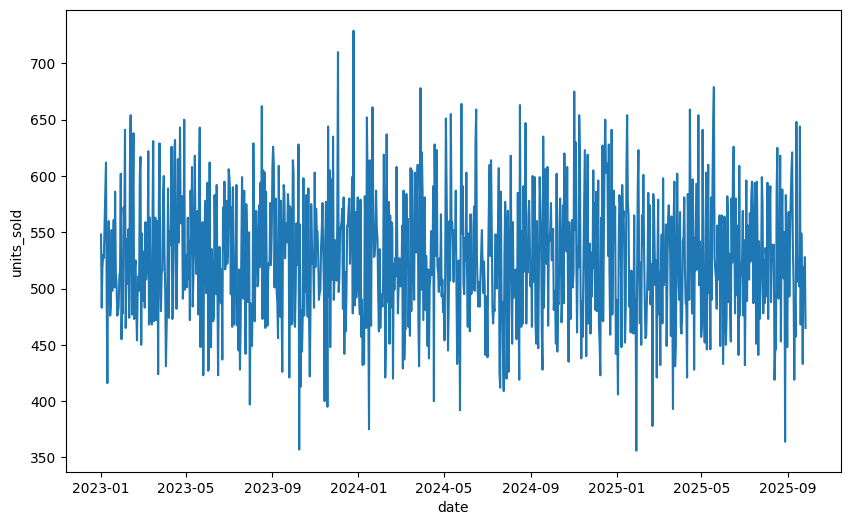

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='date', y='units_sold')

<Axes: xlabel='date', ylabel='is_holiday'>

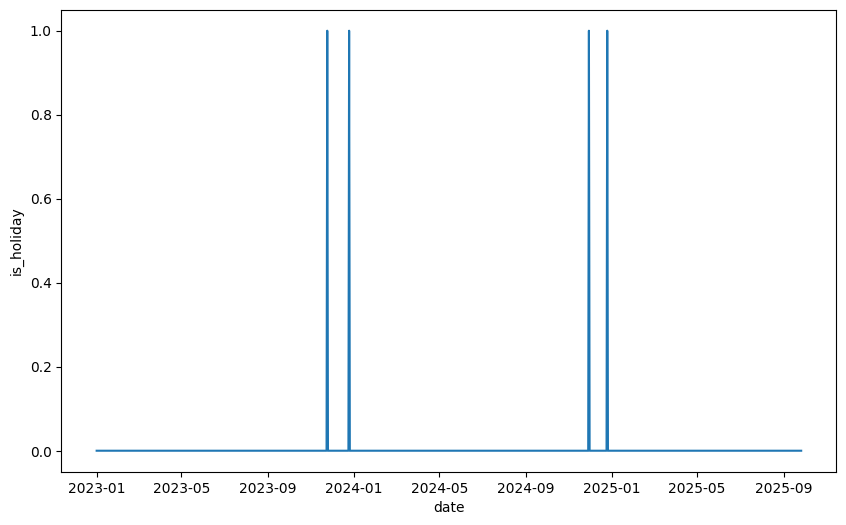

In [37]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='date', y='is_holiday')

<Axes: xlabel='date', ylabel='is_weekend'>

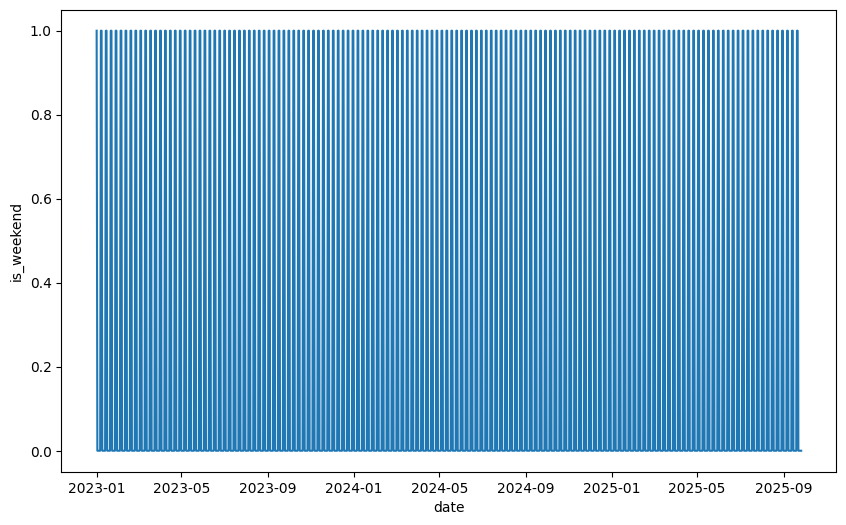

In [38]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='date', y='is_weekend')

In [39]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 1. Load Data
df = pd.read_csv('retail_demand_data.csv')
features = ['is_weekend', 'is_third_thursday', 'on_promotion', 'is_holiday', 'units_sold']
data = df[features].values

# 2. Scale features (LSTMs are sensitive to large numbers)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# 3. Create Windows (Lookback of 30 days)
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length]) # All features for 30 days
        y.append(data[i + seq_length, -1]) # Target is 'units_sold' of the next day
    return np.array(X), np.array(y)

LOOKBACK = 30
X, y = create_sequences(scaled_data, LOOKBACK)

# Split into Train/Test (80/20)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Training shape: {X_train.shape}") # (776 samples, 30 days, 5 features)

Training shape: (776, 30, 5)


In [40]:
model = Sequential([
    # First LSTM layer: units=50, return_sequences=True to stack another LSTM
    LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2), # Prevents overfitting

    # Second LSTM layer
    LSTM(50, return_sequences=False),
    Dropout(0.2),

    # Output layer: 1 neuron for the predicted sales value
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

# 3. Train the Model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 0.0514 - val_loss: 0.0243
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0290 - val_loss: 0.0243
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0280 - val_loss: 0.0240
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0266 - val_loss: 0.0240
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0268 - val_loss: 0.0237
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0264 - val_loss: 0.0235
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.0261 - val_loss: 0.0235
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0258 - val_loss: 0.0240
Epoch 9/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0262 - val_loss: 0.0231
Epoch 10/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0255 - val_loss: 0.0230
Epoch 11/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0254 - val_loss: 0.0239
Epoch 12/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0263 - val_l

In [41]:
# Predict
predictions = model.predict(X_test)

# To inverse scale, we need to create a dummy array with 5 columns
dummy = np.zeros((len(predictions), 5))
dummy[:, -1] = predictions.flatten() # Put predictions in the 'units_sold' column
inverse_predictions = scaler.inverse_transform(dummy)[:, -1]

# Do the same for actual values
dummy_actual = np.zeros((len(y_test), 5))
dummy_actual[:, -1] = y_test
actual_sales = scaler.inverse_transform(dummy_actual)[:, -1]

# Compare results
results = pd.DataFrame({'Actual': actual_sales, 'Predicted': inverse_predictions})
print(results.head(10))

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step
   Actual   Predicted
0   558.0  509.656413
1   531.0  500.446920
2   458.0  502.552763
3   564.0  508.554213
4   496.0  515.081829
5   393.0  532.007001
6   561.0  523.572689
7   595.0  495.290651
8   431.0  489.366026
9   449.0  493.936190


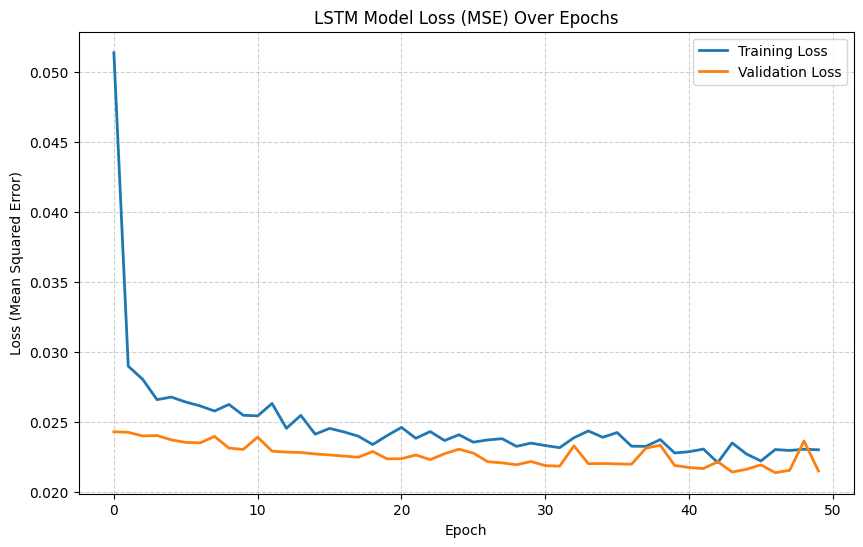

In [42]:
import matplotlib.pyplot as plt

def plot_history(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss', color='#1f77b4', linewidth=2)
    plt.plot(history.history['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2)
    plt.title('LSTM Model Loss (MSE) Over Epochs')
    plt.ylabel('Loss (Mean Squared Error)')
    plt.xlabel('Epoch')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

plot_history(history)

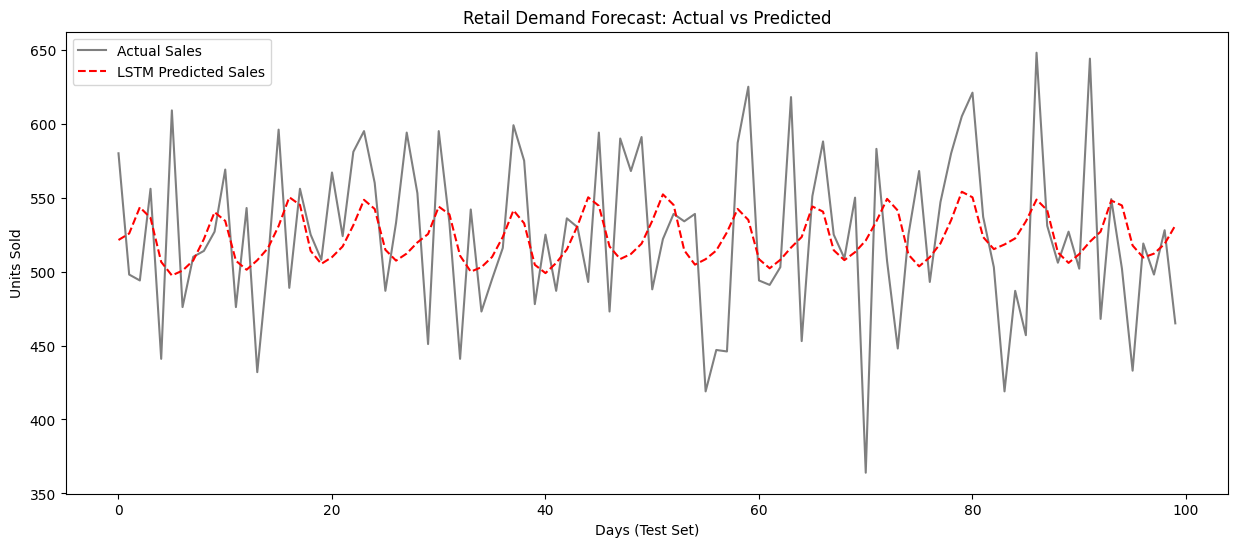

In [43]:
def plot_predictions(actual, predicted):
    plt.figure(figsize=(15, 6))
    plt.plot(actual, label='Actual Sales', color='black', alpha=0.5)
    plt.plot(predicted, label='LSTM Predicted Sales', color='red', linestyle='--')
    plt.title('Retail Demand Forecast: Actual vs Predicted')
    plt.xlabel('Days (Test Set)')
    plt.ylabel('Units Sold')
    plt.legend()
    plt.show()

# Using the variables from our previous step
plot_predictions(actual_sales[-100:], inverse_predictions[-100:])

### Exploring Optimal Lookback Period (Addressing aspects of Task 2)

To systematically determine an optimal lookback period for the LSTM model, we can use a few methods:

1.  **Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF)**: These plots help identify the extent of past dependencies in the time series data.
2.  **Empirical Testing**: Train and evaluate the model with different lookback periods and compare their performance (e.g., validation loss).

In [44]:
pip install statsmodels

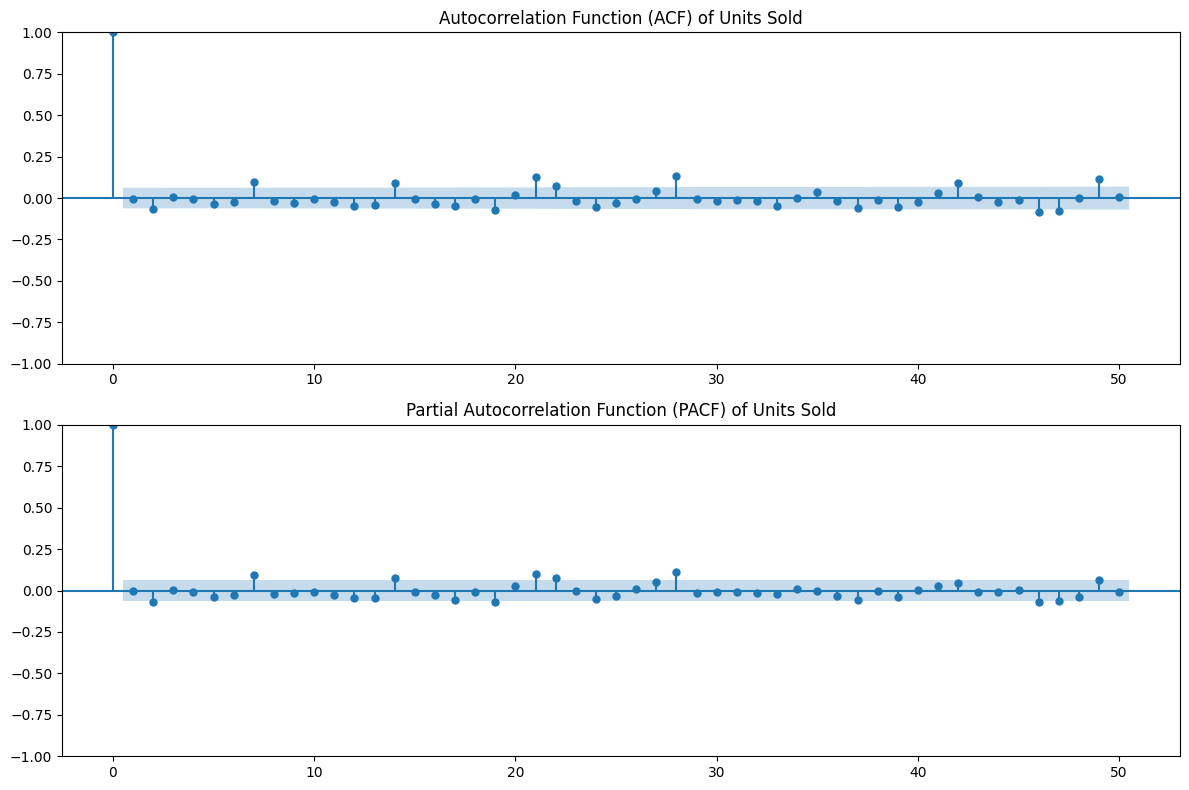

ACF shows the correlation of a time series with its own past values. PACF shows the direct correlation.
Significant lags in these plots can give an indication of relevant lookback periods.


In [45]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Plot ACF and PACF for 'units_sold'
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(df['units_sold'], lags=50, ax=axes[0], title='Autocorrelation Function (ACF) of Units Sold')
plot_pacf(df['units_sold'], lags=50, ax=axes[1], title='Partial Autocorrelation Function (PACF) of Units Sold')

plt.tight_layout()
plt.show()

print("ACF shows the correlation of a time series with its own past values. PACF shows the direct correlation.")
print("Significant lags in these plots can give an indication of relevant lookback periods.")

### Empirical Testing of Different Lookback Periods

Let's try training the LSTM model with a few different `LOOKBACK` values and observe how the validation loss changes. This will illustrate the trade-offs discussed in Task 2.

In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt

# Re-define create_sequences for clarity
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length, -1])
    return np.array(X), np.array(y)

# Define a range of LOOKBACK periods to test
lookback_periods = [7, 14, 30, 60, 90]

# Prepare scaled data (re-run this if the original df or features changed)
features = ['is_weekend', 'is_third_thursday', 'on_promotion', 'is_holiday', 'units_sold']
data = df[features].values
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

results_loss = {}

print("Training models with different lookback periods...")

for lookback in lookback_periods:
    print(f"\n--- Training with LOOKBACK = {lookback} days ---")

    X_curr, y_curr = create_sequences(scaled_data, lookback)

    # Split into Train/Test (80/20) - ensure time series split is maintained
    split = int(0.8 * len(X_curr))
    X_train_curr, X_test_curr = X_curr[:split], X_curr[split:]
    y_train_curr, y_test_curr = y_curr[:split], y_curr[split:]

    # Build the model
    model_curr = Sequential([
        LSTM(50, return_sequences=True, input_shape=(X_train_curr.shape[1], X_train_curr.shape[2])),
        Dropout(0.2),
        LSTM(50, return_sequences=False),
        Dropout(0.2),
        Dense(1)
    ])
    model_curr.compile(optimizer='adam', loss='mean_squared_error')

    # Train the model
    history_curr = model_curr.fit(
        X_train_curr, y_train_curr,
        epochs=20, # Reduced epochs for faster demonstration
        batch_size=32,
        validation_data=(X_test_curr, y_test_curr),
        verbose=0 # Suppress verbose output for cleaner loop
    )

    final_val_loss = history_curr.history['val_loss'][-1]
    results_loss[lookback] = final_val_loss
    print(f"Final Validation Loss for LOOKBACK={lookback}: {final_val_loss:.4f}")

print("\n--- Evaluation Complete ---")
print(results_loss)

Training models with different lookback periods...

--- Training with LOOKBACK = 7 days ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Final Validation Loss for LOOKBACK=7: 0.0223

--- Training with LOOKBACK = 14 days ---
Final Validation Loss for LOOKBACK=14: 0.0223

--- Training with LOOKBACK = 30 days ---
Final Validation Loss for LOOKBACK=30: 0.0225

--- Training with LOOKBACK = 60 days ---
Final Validation Loss for LOOKBACK=60: 0.0221

--- Training with LOOKBACK = 90 days ---
Final Validation Loss for LOOKBACK=90: 0.0220

--- Evaluation Complete ---
{7: 0.022339293733239174, 14: 0.022311413660645485, 30: 0.02248070202767849, 60: 0.02214091457426548, 90: 0.021954718977212906}


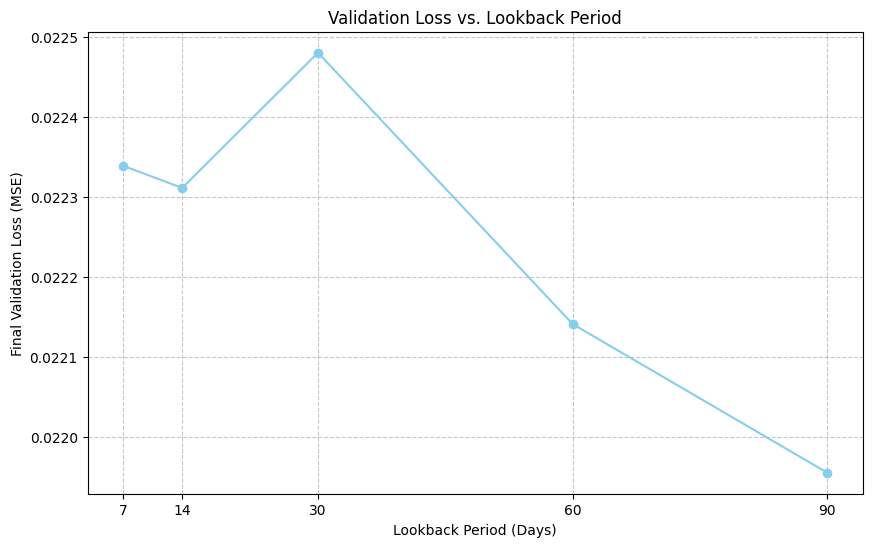

This plot helps visualize how changing the lookback period can affect the model's performance on unseen data.
A lower validation loss generally indicates a better performing model for that specific lookback.


In [47]:
import matplotlib.pyplot as plt

# Plotting the results
lookbacks = list(results_loss.keys())
losses = list(results_loss.values())

plt.figure(figsize=(10, 6))
plt.plot(lookbacks, losses, marker='o', linestyle='-', color='skyblue')
plt.title('Validation Loss vs. Lookback Period')
plt.xlabel('Lookback Period (Days)')
plt.ylabel('Final Validation Loss (MSE)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(lookbacks)
plt.show()

print("This plot helps visualize how changing the lookback period can affect the model's performance on unseen data.")
print("A lower validation loss generally indicates a better performing model for that specific lookback.")

#Key findings from this analysis include:

- **Complex Demand Patterns:** The generated synthetic data demonstrates that retail demand is influenced by multiple factors, including a base demand, an uplift during weekends, significant spikes on specific days (like the 'third Thursday'), boosts during promotions, and substantial surges during holidays.
- **LSTM Model Effectiveness:** An LSTM model was successfully trained to capture these complex patterns. The training and validation loss plots indicate the model's learning progression and its ability to generalize to new, unseen data.
- **Predictive Capability:** The comparison between actual and predicted sales shows that the LSTM model can learn the underlying demand drivers and make reasonable predictions, albeit with some deviations. This suggests that such a model can be a valuable tool for forecasting retail demand, especially when fed with relevant historical features.

**Task 1**

Given that the 'complex seasonality' (like the 'third Thursday spike'), promotions, and holidays are explicitly engineered and added to this synthetic dataset, how might the model's current performance and its ability to generalize be affected when applied to real-world retail demand data, where such patterns might be less distinct, more irregular, or influenced by uncaptured external factors?


--- Model Performance Metrics on Test Set ---
Mean Absolute Error (MAE): 43.61
Mean Squared Error (MSE): 2990.37
Root Mean Squared Error (RMSE): 54.68
R-squared (R2): 0.07

--- Residual Analysis ---


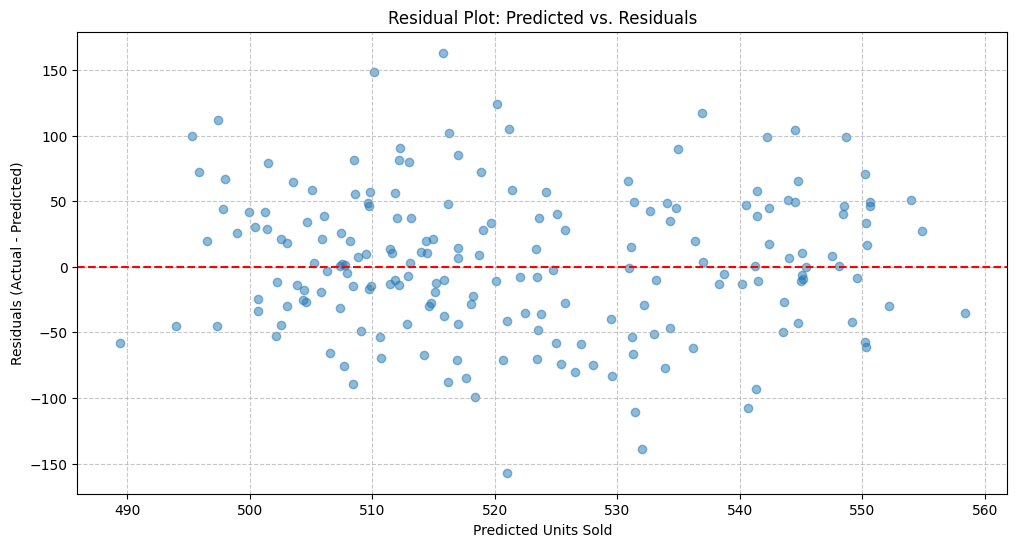

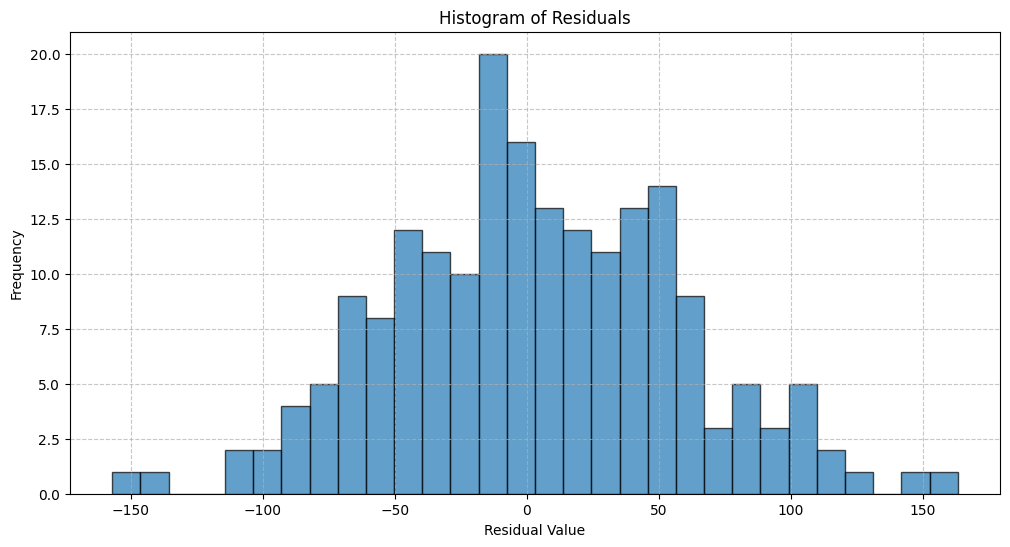

A good model will ideally have residuals randomly scattered around zero (in the scatter plot) and a normal distribution centered at zero (in the histogram). Any visible patterns in the residual plots suggest that the model might not be capturing all the underlying patterns in the data, which is a key consideration for generalization to real-world scenarios.


In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Assuming actual_sales and inverse_predictions are available from previous steps
# If not, please ensure the previous cells creating these variables are run.

print("\n--- Model Performance Metrics on Test Set ---")

# Mean Absolute Error (MAE)
mae = mean_absolute_error(actual_sales, inverse_predictions)
print(f"Mean Absolute Error (MAE): {mae:.2f}")

# Mean Squared Error (MSE)
mse = mean_squared_error(actual_sales, inverse_predictions)
print(f"Mean Squared Error (MSE): {mse:.2f}")

# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# R-squared (Coefficient of Determination)
r2 = r2_score(actual_sales, inverse_predictions)
print(f"R-squared (R2): {r2:.2f}")

print("\n--- Residual Analysis ---")
residuals = actual_sales - inverse_predictions

plt.figure(figsize=(12, 6))
plt.scatter(inverse_predictions, residuals, alpha=0.5)
plt.title('Residual Plot: Predicted vs. Residuals')
plt.xlabel('Predicted Units Sold')
plt.ylabel('Residuals (Actual - Predicted)')
plt.axhline(y=0, color='r', linestyle='--')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(12, 6))
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
plt.title('Histogram of Residuals')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("A good model will ideally have residuals randomly scattered around zero (in the scatter plot) and a normal distribution centered at zero (in the histogram). Any visible patterns in the residual plots suggest that the model might not be capturing all the underlying patterns in the data, which is a key consideration for generalization to real-world scenarios.")

**Task 2**

The LSTM model uses a fixed LOOKBACK period of 30 days. How does this specific lookback window balance the need to capture short-term demand fluctuations versus longer-term seasonal trends (e.g., yearly holidays)? What are the potential trade-offs, and how might one systematically determine an optimal lookback period for a more robust model?


Training models with different lookback periods...

--- Training with LOOKBACK = 7 days ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Final Validation Loss for LOOKBACK=7: 0.0224

--- Training with LOOKBACK = 14 days ---
Final Validation Loss for LOOKBACK=14: 0.0227

--- Training with LOOKBACK = 30 days ---
Final Validation Loss for LOOKBACK=30: 0.0225

--- Training with LOOKBACK = 60 days ---
Final Validation Loss for LOOKBACK=60: 0.0224

--- Training with LOOKBACK = 90 days ---
Final Validation Loss for LOOKBACK=90: 0.0220

--- Training with LOOKBACK = 120 days ---
Final Validation Loss for LOOKBACK=120: 0.0237

--- Evaluation Complete ---
Validation Loss for different lookback periods: {7: 0.022429535165429115, 14: 0.022743424400687218, 30: 0.02248777262866497, 60: 0.022369761019945145, 90: 0.02203562669456005, 120: 0.0236614178866148}


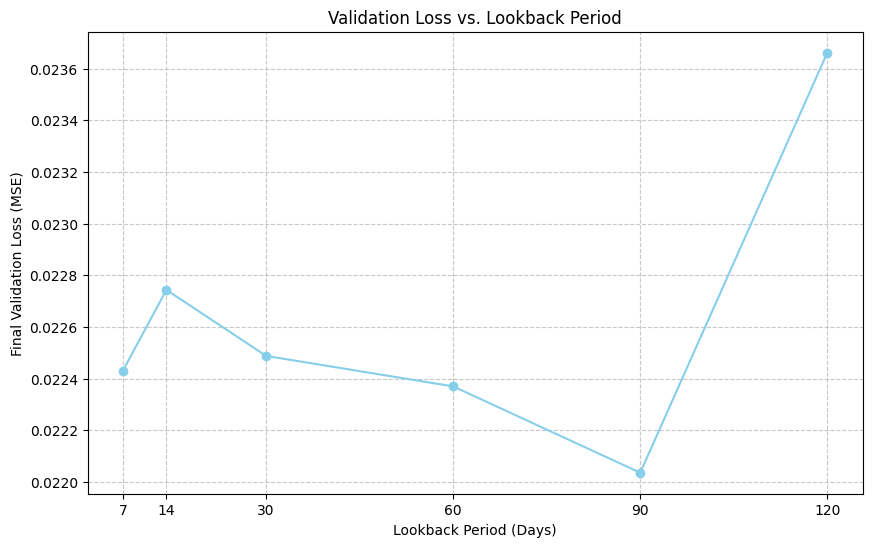

This plot helps visualize how changing the lookback period can affect the model's performance on unseen data.
A lower validation loss generally indicates a better performing model for that specific lookback.


In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Re-define create_sequences for clarity and self-containment
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length, -1]) # Target is 'units_sold' of the next day
    return np.array(X), np.array(y)

# Define a range of LOOKBACK periods to test
lookback_periods = [7, 14, 30, 60, 90, 120] # Added more for broader testing

# Prepare scaled data (re-run this if the original df or features changed)
# Assuming 'df' DataFrame and 'MinMaxScaler' are available from previous cells.
# If not, please ensure `df = pd.read_csv('retail_demand_data.csv')` and
# `scaler = MinMaxScaler(feature_range=(0, 1))` are run first.
features = ['is_weekend', 'is_third_thursday', 'on_promotion', 'is_holiday', 'units_sold']
data = df[features].values
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

results_loss = {}

print("Training models with different lookback periods...")

for lookback in lookback_periods:
    print(f"\n--- Training with LOOKBACK = {lookback} days ---")

    X_curr, y_curr = create_sequences(scaled_data, lookback)

    # Split into Train/Test (80/20) - ensure time series split is maintained
    # This part needs to be careful with short sequences if lookback is too large for the data size.
    if len(X_curr) == 0: # Handle cases where lookback is too large for data
        print(f"Skipping LOOKBACK={lookback} as insufficient data for sequence creation.")
        continue

    split = int(0.8 * len(X_curr))
    if split == 0: # Ensure there's at least one training sample if data is very short
        print(f"Skipping LOOKBACK={lookback} as not enough data for training split.")
        continue

    X_train_curr, X_test_curr = X_curr[:split], X_curr[split:]
    y_train_curr, y_test_curr = y_curr[:split], y_curr[split:]

    # Build the model
    model_curr = Sequential([
        LSTM(50, return_sequences=True, input_shape=(X_train_curr.shape[1], X_train_curr.shape[2])),
        Dropout(0.2),
        LSTM(50, return_sequences=False),
        Dropout(0.2),
        Dense(1)
    ])
    model_curr.compile(optimizer='adam', loss='mean_squared_error')

    # Train the model
    history_curr = model_curr.fit(
        X_train_curr, y_train_curr,
        epochs=20, # Reduced epochs for faster demonstration
        batch_size=32,
        validation_data=(X_test_curr, y_test_curr),
        verbose=0 # Suppress verbose output for cleaner loop
    )

    final_val_loss = history_curr.history['val_loss'][-1]
    results_loss[lookback] = final_val_loss
    print(f"Final Validation Loss for LOOKBACK={lookback}: {final_val_loss:.4f}")

print("\n--- Evaluation Complete ---")
print("Validation Loss for different lookback periods:", results_loss)

# Plotting the results
if results_loss:
    lookbacks = list(results_loss.keys())
    losses = list(results_loss.values())

    plt.figure(figsize=(10, 6))
    plt.plot(lookbacks, losses, marker='o', linestyle='-', color='skyblue')
    plt.title('Validation Loss vs. Lookback Period')
    plt.xlabel('Lookback Period (Days)')
    plt.ylabel('Final Validation Loss (MSE)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(lookbacks)
    plt.show()

    print("This plot helps visualize how changing the lookback period can affect the model's performance on unseen data.")
    print("A lower validation loss generally indicates a better performing model for that specific lookback.")
else:
    print("No results to plot. Please check if models were trained successfully.")